In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoint-24535/config.json
/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoint-24535/trainer_state.json
/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoint-24535/training_args.bin
/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoint-24535/scaler.pt
/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoint-24535/scheduler.pt
/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoint-24535/model.safetensors
/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoint-24535/optimizer.pt
/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoint-24535/rng_state.pth
/kaggle/input/datasets/quan

In [2]:
!pip install javalang torch torchvision torchaudio transformers torch-geometric scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.8 MB/s eta 0:00:0000:01


In [3]:
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from collections import defaultdict
import json
import numpy as np
import matplotlib.pyplot as plt

import javalang
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from torch_geometric.nn import GATConv, global_mean_pool
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

@dataclass
class Config:
    codebert_name: str = "microsoft/codebert-base"
    max_code_length: int = 256
    max_ast_nodes: int = 256
    max_dfg_nodes: int = 128
    hidden_dim: int = 256
    num_classes: int = 4
    dropout: float = 0.2
    freeze_codebert: bool = True

cfg = Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [9]:
@dataclass
class ASTNodeData:
    node_id: int
    node_type: str
    node_name: str = ""
    depth: int = 0
    child_count: int = 0
    flags: Dict[str, int] = field(default_factory=dict)

@dataclass
class ASTEdgeData:
    src: int
    dst: int
    edge_type: str

@dataclass
class ASTGraphSample:
    code: str
    nodes: List[ASTNodeData]
    edges: List[ASTEdgeData]

@dataclass
class DFGNodeData:
    node_id: int
    stmt_type: str
    defs: List[str] = field(default_factory=list)
    uses: List[str] = field(default_factory=list)
    unknown: List[str] = field(default_factory=list)
    text: str = ""

@dataclass
class DFGEdgeData:
    src: int
    dst: int
    edge_type: str

@dataclass
class DFGGraphSample:
    code: str
    nodes: List[DFGNodeData]
    edges: List[DFGEdgeData]

In [10]:
def safe_get_name(node) -> str:
    for attr in ["name", "member", "qualifier", "value"]:
        if hasattr(node, attr):
            val = getattr(node, attr)
            if isinstance(val, str):
                return val
    return ""

def iter_children(node):
    if not isinstance(node, javalang.ast.Node):
        return
    for attr_name in node.attrs:
        value = getattr(node, attr_name)
        if isinstance(value, javalang.ast.Node):
            yield value
        elif isinstance(value, list):
            for item in value:
                if isinstance(item, javalang.ast.Node):
                    yield item

def walk_tree(node):
    if not isinstance(node, javalang.ast.Node):
        return
    yield node
    for child in iter_children(node):
        yield from walk_tree(child)

def parse_java_method(code: str):
    tokens = javalang.tokenizer.tokenize(code)
    parser = javalang.parser.Parser(tokens)
    return parser.parse_member_declaration()

In [11]:
def get_ast_flags(node) -> Dict[str, int]:
    t = type(node).__name__
    return {
        "is_call": int(t == "MethodInvocation"),
        "is_if": int(t == "IfStatement"),
        "is_loop": int(t in {"ForStatement", "WhileStatement", "DoStatement"}),
        "is_try": int(t == "TryStatement"),
        "is_catch": int(t == "CatchClause"),
        "is_return": int(t == "ReturnStatement"),
        "is_assignment": int(t == "Assignment"),
        "is_declaration": int(t in {"LocalVariableDeclaration", "VariableDeclarator", "FormalParameter"}),
    }

def build_ast_graph(code: str, max_nodes: int = 256) -> ASTGraphSample:
    root = parse_java_method(code)
    nodes, edges = [], []

    def dfs(node, depth=0, parent_id=None):
        if len(nodes) >= max_nodes or not isinstance(node, javalang.ast.Node):
            return

        node_id = len(nodes)
        children = list(iter_children(node))

        nodes.append(ASTNodeData(
            node_id=node_id,
            node_type=type(node).__name__,
            node_name=safe_get_name(node),
            depth=depth,
            child_count=len(children),
            flags=get_ast_flags(node),
        ))

        if parent_id is not None:
            edges.append(ASTEdgeData(parent_id, node_id, "PARENT_CHILD"))

        prev_child_id = None
        for child in children:
            if len(nodes) >= max_nodes:
                break
            next_id = len(nodes)
            dfs(child, depth + 1, node_id)
            if next_id < len(nodes):
                if prev_child_id is not None:
                    edges.append(ASTEdgeData(prev_child_id, next_id, "NEXT_SIBLING"))
                prev_child_id = next_id

    dfs(root, 0, None)
    return ASTGraphSample(code=code, nodes=nodes, edges=edges)

In [34]:
print("=====Cell 5 done")

=====Cell 5 done


In [13]:
STATEMENT_TYPES = {
    "LocalVariableDeclaration",
    "StatementExpression",
    "IfStatement",
    "ForStatement",
    "WhileStatement",
    "DoStatement",
    "TryStatement",
    "ReturnStatement",
}

def is_statement_node(node) -> bool:
    return type(node).__name__ in STATEMENT_TYPES

def extract_statements(root):
    return [node for node in walk_tree(root) if is_statement_node(node)]

def extract_identifiers(node) -> List[str]:
    vars_ = []
    for n in walk_tree(node):
        t = type(n).__name__
        if t == "MemberReference":
            if hasattr(n, "member") and isinstance(n.member, str):
                vars_.append(n.member)
        elif t == "FormalParameter":
            if hasattr(n, "name") and isinstance(n.name, str):
                vars_.append(n.name)
        elif t == "VariableDeclarator":
            if hasattr(n, "name") and isinstance(n.name, str):
                vars_.append(n.name)
    return vars_

def dedup_keep_order(xs: List[str]) -> List[str]:
    seen, out = set(), []
    for x in xs:
        if x not in seen:
            out.append(x)
            seen.add(x)
    return out

def extract_def_use_from_statement(stmt):
    stmt_type = type(stmt).__name__
    defs, uses, unknown = [], [], []

    if stmt_type == "LocalVariableDeclaration":
        declarators = getattr(stmt, "declarators", []) or []
        for d in declarators:
            if hasattr(d, "name") and d.name:
                defs.append(d.name)
            if hasattr(d, "initializer") and d.initializer is not None:
                uses.extend(extract_identifiers(d.initializer))

    elif stmt_type == "StatementExpression":
        expr = getattr(stmt, "expression", None)
        if expr is not None:
            expr_type = type(expr).__name__
            if expr_type == "Assignment":
                left = getattr(expr, "expressionl", None)
                right = getattr(expr, "value", None)
                if left is not None:
                    defs.extend(extract_identifiers(left))
                if right is not None:
                    uses.extend(extract_identifiers(right))
            else:
                uses.extend(extract_identifiers(expr))

    elif stmt_type == "IfStatement":
        cond = getattr(stmt, "condition", None)
        if cond is not None:
            uses.extend(extract_identifiers(cond))

    elif stmt_type in {"ForStatement", "WhileStatement", "DoStatement", "TryStatement"}:
        uses.extend(extract_identifiers(stmt))

    elif stmt_type == "ReturnStatement":
        expr = getattr(stmt, "expression", None)
        if expr is not None:
            uses.extend(extract_identifiers(expr))
    else:
        uses.extend(extract_identifiers(stmt))

    return (
        dedup_keep_order(defs),
        dedup_keep_order(uses),
        dedup_keep_order(unknown),
    )

def build_dfg_graph(code: str, max_nodes: int = 128) -> DFGGraphSample:
    root = parse_java_method(code)
    statements = extract_statements(root)[:max_nodes]

    nodes, edges = [], []
    stmt_infos = []

    for i, stmt in enumerate(statements):
        defs, uses, unknown = extract_def_use_from_statement(stmt)
        nodes.append(DFGNodeData(
            node_id=i,
            stmt_type=type(stmt).__name__,
            defs=defs,
            uses=uses,
            unknown=unknown,
            text=type(stmt).__name__,
        ))
        stmt_infos.append({"defs": defs, "uses": uses, "unknown": unknown})

    # sequential reaching-def baseline
    for j, info in enumerate(stmt_infos):
        for used_var in info["uses"]:
            for i in range(j - 1, -1, -1):
                if used_var in stmt_infos[i]["defs"]:
                    edges.append(DFGEdgeData(i, j, "DATA_DEP"))
                    break

    return DFGGraphSample(code=code, nodes=nodes, edges=edges)

In [14]:
class SimpleVocab:
    def __init__(self):
        self.token2id = {"<UNK>": 0}
        self.id2token = ["<UNK>"]

    def add(self, token: str):
        if token not in self.token2id:
            self.token2id[token] = len(self.id2token)
            self.id2token.append(token)

    def encode(self, token: str) -> int:
        return self.token2id.get(token, 0)

    def __len__(self):
        return len(self.id2token)

ast_type_vocab = SimpleVocab()
dfg_stmt_vocab = SimpleVocab()
var_name_vocab = SimpleVocab()

def build_vocabs(ast_samples, dfg_samples):
    for gs in ast_samples:
        for n in gs.nodes:
            ast_type_vocab.add(n.node_type)
    for gs in dfg_samples:
        for n in gs.nodes:
            dfg_stmt_vocab.add(n.stmt_type)
            for v in n.defs + n.uses + n.unknown:
                var_name_vocab.add(v)

def encode_ast_graph(sample: ASTGraphSample):
    edge_type_map = {"PARENT_CHILD": 0, "NEXT_SIBLING": 1}
    node_type_ids, numeric_feats, edge_index, edge_type_ids = [], [], [], []

    for node in sample.nodes:
        node_type_ids.append(ast_type_vocab.encode(node.node_type))
        numeric_feats.append([
            node.depth,
            node.child_count,
            node.flags["is_call"],
            node.flags["is_if"],
            node.flags["is_loop"],
            node.flags["is_try"],
            node.flags["is_catch"],
            node.flags["is_return"],
            node.flags["is_assignment"],
            node.flags["is_declaration"],
        ])

    for e in sample.edges:
        edge_index.append([e.src, e.dst])
        edge_type_ids.append(edge_type_map[e.edge_type])

    return {
        "node_type_ids": torch.tensor(node_type_ids, dtype=torch.long),
        "numeric_feats": torch.tensor(numeric_feats, dtype=torch.float),
        "edge_index": torch.tensor(edge_index, dtype=torch.long).t().contiguous() if edge_index else torch.zeros((2, 0), dtype=torch.long),
        "edge_type_ids": torch.tensor(edge_type_ids, dtype=torch.long),
    }

def mean_var_id(vars_: List[str]) -> int:
    if not vars_:
        return 0
    ids = [var_name_vocab.encode(v) for v in vars_]
    return int(sum(ids) / len(ids))

def encode_dfg_graph(sample: DFGGraphSample):
    edge_type_map = {"DATA_DEP": 0}
    stmt_type_ids, numeric_feats, edge_index, edge_type_ids = [], [], [], []

    for node in sample.nodes:
        stmt_type_ids.append(dfg_stmt_vocab.encode(node.stmt_type))
        numeric_feats.append([
            len(node.defs),
            len(node.uses),
            len(node.unknown),
            mean_var_id(node.defs),
            mean_var_id(node.uses),
        ])

    for e in sample.edges:
        edge_index.append([e.src, e.dst])
        edge_type_ids.append(edge_type_map[e.edge_type])

    return {
        "stmt_type_ids": torch.tensor(stmt_type_ids, dtype=torch.long),
        "numeric_feats": torch.tensor(numeric_feats, dtype=torch.float),
        "edge_index": torch.tensor(edge_index, dtype=torch.long).t().contiguous() if edge_index else torch.zeros((2, 0), dtype=torch.long),
        "edge_type_ids": torch.tensor(edge_type_ids, dtype=torch.long),
    }

def add_single_batch(graph_dict, key):
    n = graph_dict[key].shape[0]
    graph_dict["batch"] = torch.zeros(n, dtype=torch.long)
    return graph_dict

In [15]:
tokenizer = AutoTokenizer.from_pretrained(cfg.codebert_name)
codebert = AutoModel.from_pretrained(cfg.codebert_name).to(device)

if cfg.freeze_codebert:
    for p in codebert.parameters():
        p.requires_grad = False
    codebert.eval()

def encode_codebert(code: str, max_length: int = 256):
    inputs = tokenizer(
        code,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = codebert(**inputs)
    return outputs.last_hidden_state[:, 0, :].cpu()

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [26]:
class ASTEncoder(nn.Module):
    def __init__(self, ast_vocab_size: int, hidden_dim: int):
        super().__init__()
        self.type_emb = nn.Embedding(ast_vocab_size, hidden_dim)
        self.feat_proj = nn.Linear(10, hidden_dim)
        self.gnn1 = GATConv(hidden_dim, hidden_dim, heads=1)
        self.gnn2 = GATConv(hidden_dim, hidden_dim, heads=1)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, node_type_ids, numeric_feats, edge_index, batch):
        x = self.type_emb(node_type_ids) + self.feat_proj(numeric_feats)
        x = F.relu(self.gnn1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.gnn2(x, edge_index))
        return global_mean_pool(x, batch)

class DFGEncoder(nn.Module):
    def __init__(self, stmt_vocab_size: int, hidden_dim: int):
        super().__init__()
        self.type_emb = nn.Embedding(stmt_vocab_size, hidden_dim)
        self.feat_proj = nn.Linear(5, hidden_dim)
        self.gnn1 = GATConv(hidden_dim, hidden_dim, heads=1)
        self.gnn2 = GATConv(hidden_dim, hidden_dim, heads=1)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, stmt_type_ids, numeric_feats, edge_index, batch):
        x = self.type_emb(stmt_type_ids) + self.feat_proj(numeric_feats)
        x = F.relu(self.gnn1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.gnn2(x, edge_index))
        return global_mean_pool(x, batch)

class GatedFusion(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.proj_a = nn.Linear(hidden_dim, hidden_dim)
        self.proj_b = nn.Linear(hidden_dim, hidden_dim)
        self.gate = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, a, b):
        a_ = self.proj_a(a)
        b_ = self.proj_b(b)
        g = torch.sigmoid(self.gate(torch.cat([a_, b_], dim=-1)))
        return g * a_ + (1 - g) * b_

class BaseEncoder(nn.Module):
    def __init__(self, ast_vocab_size, dfg_vocab_size, hidden_dim=256, codebert_dim=768):
        super().__init__()
        self.ast_encoder = ASTEncoder(ast_vocab_size, hidden_dim)
        self.dfg_encoder = DFGEncoder(dfg_vocab_size, hidden_dim)
        self.code_proj = nn.Linear(codebert_dim, hidden_dim)
        self.struct_fusion = GatedFusion(hidden_dim)
        self.final_fusion = GatedFusion(hidden_dim)

    def forward(self, code_vec, ast_graph, dfg_graph):
        h_code = self.code_proj(code_vec)
        h_ast = self.ast_encoder(
            ast_graph["node_type_ids"], ast_graph["numeric_feats"], ast_graph["edge_index"], ast_graph["batch"]
        )
        h_dfg = self.dfg_encoder(
            dfg_graph["stmt_type_ids"], dfg_graph["numeric_feats"], dfg_graph["edge_index"], dfg_graph["batch"]
        )
        h_struct = self.struct_fusion(h_ast, h_dfg)
        return self.final_fusion(h_code, h_struct)

class PairCloneClassifier(nn.Module):
    def __init__(self, ast_vocab_size, dfg_vocab_size, hidden_dim=256, num_classes=4, codebert_dim=768):
        super().__init__()
        self.base = BaseEncoder(ast_vocab_size, dfg_vocab_size, hidden_dim, codebert_dim)
        self.cls = nn.Sequential(
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, feat1, feat2):
        h1 = self.base(feat1["code_vec"], feat1["ast_graph"], feat1["dfg_graph"])
        h2 = self.base(feat2["code_vec"], feat2["ast_graph"], feat2["dfg_graph"])
        z = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=-1)
        return self.cls(z)

In [27]:
def load_idx_to_code(jsonl_path: str) -> Dict[str, str]:
    idx_to_code = {}
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            idx_to_code[str(obj["idx"])] = obj["func"]
    return idx_to_code

def load_pairs_txt(txt_path: str) -> List[Tuple[str, str, int]]:
    pairs = []
    with open(txt_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t") if "\t" in line else line.split()
            if len(parts) != 3:
                continue
            idx1, idx2, label = parts
            pairs.append((str(idx1), str(idx2), int(label)))
    return pairs

jsonl_path = "/kaggle/input/datasets/quannvh/datasemantic-clone/dataset (2)/dataset/Multiclass/data.jsonl"
train_path = "/kaggle/input/datasets/quannvh/datasemantic-clone/50000-20260403T163943Z-3-001/50000/train_50000.txt"
test_path = "/kaggle/input/datasets/quannvh/datasemantic-clone/50000-20260403T163943Z-3-001/50000/test_50000.txt"
valid_path  = "/kaggle/input/datasets/quannvh/datasemantic-clone/50000-20260403T163943Z-3-001/50000/valid_50000.txt"

idx_to_code = load_idx_to_code(jsonl_path)
train_pairs = load_pairs_txt(train_path)
valid_pairs = load_pairs_txt(valid_path)
test_pairs  = load_pairs_txt(test_path)

print(len(idx_to_code), len(train_pairs), len(valid_pairs), len(test_pairs))

9126 30000 10000 10000


In [28]:
def build_vocabs_from_pairs(pairs, idx_to_code, limit=None):
    ast_samples, dfg_samples = [], []
    iterable = pairs if limit is None else pairs[:limit]

    for idx1, idx2, _ in iterable:
        if idx1 not in idx_to_code or idx2 not in idx_to_code:
            continue
        for idx in [idx1, idx2]:
            code = idx_to_code[idx]
            try:
                ast_samples.append(build_ast_graph(code, max_nodes=cfg.max_ast_nodes))
                dfg_samples.append(build_dfg_graph(code, max_nodes=cfg.max_dfg_nodes))
            except Exception:
                pass

    build_vocabs(ast_samples, dfg_samples)

build_vocabs_from_pairs(train_pairs, idx_to_code, limit=1000)
print(len(ast_type_vocab), len(dfg_stmt_vocab), len(var_name_vocab))

50 9 2579


In [29]:
def prepare_one_code_sample(code: str) -> dict:
    # 1. CodeBERT vector
    code_vec = encode_codebert(code, max_length=cfg.max_code_length)  # shape: (1, 768)

    # 2. AST graph
    ast_sample = build_ast_graph(code, max_nodes=cfg.max_ast_nodes)
    ast_graph = encode_ast_graph(ast_sample)
    ast_graph["batch"] = torch.zeros(ast_graph["node_type_ids"].shape[0], dtype=torch.long)

    # 3. DFG graph
    dfg_sample = build_dfg_graph(code, max_nodes=cfg.max_dfg_nodes)
    dfg_graph = encode_dfg_graph(dfg_sample)
    dfg_graph["batch"] = torch.zeros(dfg_graph["stmt_type_ids"].shape[0], dtype=torch.long)

    return {
        "code_vec": code_vec,   # Tensor (1, 768)
        "ast_graph": ast_graph,
        "dfg_graph": dfg_graph,
    }

In [30]:
import os

feature_path = "/kaggle/working/precomputed_features.pt"

if not os.path.exists(feature_path):
    print("Đang tính feature....")
    precomputed_features = {}
    
    # Gom tất cả các ID code thực sự được dùng để tránh tính thừa
    used_indices = set()
    for splits in [train_pairs, valid_pairs, test_pairs]:
        for idx1, idx2, _ in splits:
            used_indices.add(idx1)
            used_indices.add(idx2)

    count = 0
    total = len(used_indices)
    
    for idx in used_indices:
        if idx in idx_to_code:
            try:
                # Gọi hàm prepare_one_code_sample từ Cell 12 cũ (đảm bảo bạn đã run hàm đó)
                precomputed_features[idx] = prepare_one_code_sample(idx_to_code[idx])
            except Exception:
                pass # Bỏ qua các code bị lỗi cú pháp không parse được AST
        
        count += 1
        if count % 500 == 0:
            print(f"Đã xử lý {count}/{total} code snippets...")

    # Lưu xuống ổ cứng
    torch.save(precomputed_features, feature_path)
    print("Xong! Đã lưu precomputed_features.pt")
else:
    print("Đã tìm thấy file feature, load vào RAM thôi!")
    
# Load toàn bộ data đã tính vào RAM
precomputed_features = torch.load(feature_path)
print(f"Đã load {len(precomputed_features)} features vào RAM sẵn sàng train.")

Đã tìm thấy file feature, load vào RAM thôi!
Đã load 5886 features vào RAM sẵn sàng train.


In [31]:
def batch_graphs(graph_list, node_key="node_type_ids"):
    node_ids, numeric_feats, edge_index, edge_type_ids, batch_vec = [], [], [], [], []
    node_offset = 0
    
    for i, g in enumerate(graph_list):
        num_nodes = g[node_key].shape[0]
        if num_nodes == 0: continue
            
        node_ids.append(g[node_key])
        numeric_feats.append(g["numeric_feats"])
        
        if g["edge_index"].shape[1] > 0:
            edge_index.append(g["edge_index"] + node_offset)
            edge_type_ids.append(g["edge_type_ids"])
            
        batch_vec.append(torch.full((num_nodes,), i, dtype=torch.long))
        node_offset += num_nodes

    return {
        node_key: torch.cat(node_ids, dim=0) if node_ids else torch.tensor([], dtype=torch.long),
        "numeric_feats": torch.cat(numeric_feats, dim=0) if numeric_feats else torch.tensor([], dtype=torch.float),
        "edge_index": torch.cat(edge_index, dim=1) if edge_index else torch.zeros((2, 0), dtype=torch.long),
        "edge_type_ids": torch.cat(edge_type_ids, dim=0) if edge_type_ids else torch.tensor([], dtype=torch.long),
        "batch": torch.cat(batch_vec, dim=0) if batch_vec else torch.tensor([], dtype=torch.long)
    }

class ClonePairDatasetOptimized(Dataset):
    def __init__(self, pairs, precomputed_features):
        self.samples = []
        for idx1, idx2, label in pairs:
            if idx1 in precomputed_features and idx2 in precomputed_features:
                feat1, feat2 = precomputed_features[idx1], precomputed_features[idx2]
                if feat1["ast_graph"]["node_type_ids"].numel() == 0 or feat1["dfg_graph"]["stmt_type_ids"].numel() == 0 or \
                   feat2["ast_graph"]["node_type_ids"].numel() == 0 or feat2["dfg_graph"]["stmt_type_ids"].numel() == 0:
                    continue
                self.samples.append((idx1, idx2, label))
        self.features = precomputed_features

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        idx1, idx2, label = self.samples[i]
        return {
            "idx1": idx1,
            "idx2": idx2,
            "feat1": self.features[idx1], 
            "feat2": self.features[idx2], 
            "label": label
            }

def pair_collate_fn_truely_batched(batch):
    if len(batch) == 0: return None
    
    # CHÚ Ý ĐOẠN NÀY ĐÃ ĐƯỢC ÉP KEY CHUẨN XÁC
    feat1_ast = batch_graphs([item["feat1"]["ast_graph"] for item in batch], node_key="node_type_ids")
    feat1_dfg = batch_graphs([item["feat1"]["dfg_graph"] for item in batch], node_key="stmt_type_ids")
    feat1_code = torch.cat([item["feat1"]["code_vec"] for item in batch], dim=0)

    feat2_ast = batch_graphs([item["feat2"]["ast_graph"] for item in batch], node_key="node_type_ids")
    feat2_dfg = batch_graphs([item["feat2"]["dfg_graph"] for item in batch], node_key="stmt_type_ids")
    feat2_code = torch.cat([item["feat2"]["code_vec"] for item in batch], dim=0)

    labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
    idx1_list = [item["idx1"] for item in batch]
    idx2_list = [item["idx2"] for item in batch]
    
    return {
        "idx1": idx1_list,
        "idx2": idx2_list,
        "feat1": {"ast_graph": feat1_ast, "dfg_graph": feat1_dfg, "code_vec": feat1_code},
        "feat2": {"ast_graph": feat2_ast, "dfg_graph": feat2_dfg, "code_vec": feat2_code},
        "label": labels
    }
train_dataset = ClonePairDatasetOptimized(train_pairs, precomputed_features)
valid_dataset = ClonePairDatasetOptimized(valid_pairs, precomputed_features)
test_dataset  = ClonePairDatasetOptimized(test_pairs, precomputed_features)
BATCH_SIZE = 16 

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=pair_collate_fn_truely_batched, num_workers=4)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=pair_collate_fn_truely_batched, num_workers=4)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=pair_collate_fn_truely_batched, num_workers=4)

print(f"Train batches: {len(train_loader)} | Valid batches: {len(valid_loader)}")

Train batches: 1227 | Valid batches: 409


In [44]:
print(len(train_loader))
print(len(valid_loader))
print(len(test_loader))

1227
409
406


In [37]:
pair_model = PairCloneClassifier(
    ast_vocab_size=len(ast_type_vocab),
    dfg_vocab_size=len(dfg_stmt_vocab),
    hidden_dim=cfg.hidden_dim,
    num_classes=cfg.num_classes,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    [p for p in pair_model.parameters() if p.requires_grad],
    lr=1e-4
)

In [35]:
def move_feat_to_device(sample_feat, device):
    return {
        "code_vec": sample_feat["code_vec"].to(device),
        "ast_graph": {k: v.to(device) for k, v in sample_feat["ast_graph"].items()},
        "dfg_graph": {k: v.to(device) for k, v in sample_feat["dfg_graph"].items()},
    }

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_count = 0.0, 0

    for batch in loader:
        if batch is None: continue

        optimizer.zero_grad()
        
        # Đẩy nguyên 1 mẻ 16 samples lên GPU cùng lúc
        feat1 = move_feat_to_device(batch["feat1"], device)
        feat2 = move_feat_to_device(batch["feat2"], device)
        label = batch["label"].to(device)

        logits = model(feat1, feat2)
        loss = criterion(logits, label)
        loss.backward()
        optimizer.step()

        # Tính toán loss chuẩn cho cả batch
        batch_size = label.size(0)
        total_loss += float(loss.item()) * batch_size
        total_count += batch_size

    return total_loss / max(total_count, 1)

def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_count = 0.0, 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in loader:
            if batch is None: continue

            feat1 = move_feat_to_device(batch["feat1"], device)
            feat2 = move_feat_to_device(batch["feat2"], device)
            label = batch["label"].to(device)

            logits = model(feat1, feat2)
            loss = criterion(logits, label)

            batch_size = label.size(0)
            total_loss += float(loss.item()) * batch_size
            total_count += batch_size

            pred = torch.argmax(logits, dim=-1)
            y_true.extend(label.cpu().tolist())
            y_pred.extend(pred.cpu().tolist())

    # ... (Giữ nguyên phần tính accuracy, precision, recall ở dưới như cũ) ...
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    return {
        "loss": total_loss / max(total_count, 1),
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class,
        "f1_per_class": f1_per_class,
        "support_per_class": support_per_class,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
    }

In [36]:
def print_metrics(metrics, class_names=None):
    class_names = class_names or ["Type-1", "Type-2", "Type-3", "Type-4"]
    print(f"loss            : {metrics['loss']:.4f}")
    print(f"accuracy        : {metrics['accuracy']:.4f}")
    print(f"precision_macro : {metrics['precision_macro']:.4f}")
    print(f"recall_macro    : {metrics['recall_macro']:.4f}")
    print(f"f1_macro        : {metrics['f1_macro']:.4f}")
    print()
    for i, name in enumerate(class_names):
        print(
            f"{name:7s} | "
            f"P={metrics['precision_per_class'][i]:.4f}  "
            f"R={metrics['recall_per_class'][i]:.4f}  "
            f"F1={metrics['f1_per_class'][i]:.4f}  "
            f"Support={metrics['support_per_class'][i]}"
        )

def plot_confusion_matrix_percent(metrics, class_names=None, figsize=(7, 7)):
    class_names = class_names or ["Type-1", "Type-2", "Type-3", "Type-4"]
    cm = metrics["confusion_matrix"].astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    cm_percent = cm / row_sums * 100.0

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_percent, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        title='Confusion Matrix (%)',
        ylabel='True label',
        xlabel='Predicted label'
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm_percent.max() / 2.0
    for i in range(cm_percent.shape[0]):
        for j in range(cm_percent.shape[1]):
            ax.text(
                j, i, f"{cm_percent[i, j]:.2f}%",
                ha="center", va="center",
                color="white" if cm_percent[i, j] > thresh else "black"
            )

    fig.tight_layout()
    plt.show()

In [48]:
print(device)
print(next(pair_model.parameters()).device)

cpu
cpu


In [49]:
# import time 

# start_time = time.time()
# best_f1 = -1.0
# best_state = None
# num_epochs = 30

# for epoch in range(num_epochs):
#     epoch_start_time = time.time()
#     train_loss = train_one_epoch(pair_model, train_loader, optimizer, criterion, device)
#     valid_metrics = eval_one_epoch(pair_model, valid_loader, criterion, device)

#     epoch_time = time.time() - epoch_start_time
#     print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")
#     print(f"train_loss: {train_loss:.4f}")
#     print_metrics(valid_metrics)

#     print(f"\nTime training epoch: {epoch_time} seconds")
#     if valid_metrics["f1_macro"] > best_f1:
#         best_f1 = valid_metrics["f1_macro"]
#         best_state = {k: v.cpu() for k, v in pair_model.state_dict().items()}
#         torch.save(best_state,"/kaggle/working/best_model.pth")
#         print("Save model successedfully")
#         print(f"New best macro F1: {best_f1:.4f}")
# total_training_time = time.time() - start_time
# print(f"Time trainning for all epochs: {total_training_time} seconds")
# hours = int(total_training_time // 3600)
# minutes = int((total_training_time % 3600) // 60)
# seconds = int(total_training_time % 60)

# print("\n===== TRAINING FINISHED =====")
# print(f"Total training time: {hours}h {minutes}m {seconds}s")
    

In [50]:
test = 159393436
demo = 939483
print(test/demo)

169.66079854558305


✅ Đã load trọng số hội tụ tốt nhất!

⏳ Đang chạy đánh giá trên tập Test...

📊 KẾT QUẢ TẬP TEST:
--------------------------------------------------
loss            : 0.1430
accuracy        : 0.9421
precision_macro : 0.9458
recall_macro    : 0.9455
f1_macro        : 0.9454

Type-1  | P=0.9963  R=1.0000  F1=0.9982  Support=812
Type-2  | P=0.9964  R=0.9973  F1=0.9969  Support=2234
Type-3  | P=0.8745  R=0.9181  F1=0.8957  Support=1745
Type-4  | P=0.9162  R=0.8667  F1=0.8908  Support=1703

🎨 Đang vẽ Confusion Matrix...


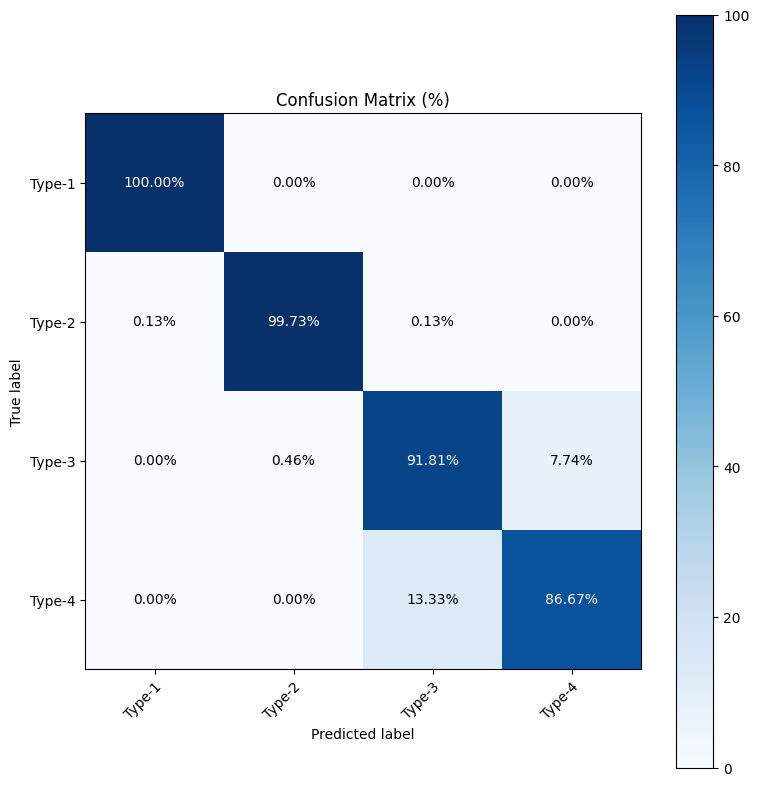

In [54]:
# === Cell 17: Load Best Model & Vẽ Confusion Matrix ===
best_state = torch.load('/kaggle/working/best_model.pth')
if best_state is not None:
    pair_model.load_state_dict(best_state)
    print("✅ Đã load trọng số hội tụ tốt nhất!")

# Đảm bảo model vẫn ở trên GPU để chạy cho nhanh
pair_model.to(device)

print("\n⏳ Đang chạy đánh giá trên tập Test...")
# start_time = time.time()
test_metrics = eval_one_epoch(pair_model, test_loader, criterion, device)
# total_time = time.time() - start_time
# print(f"Total time for testing: {total_time}")
nums_sample = len(test_loader.dataset)
# print(f"Avg time for valid test for each sample: {total_time/nums_sample} seconds")

print("\n📊 KẾT QUẢ TẬP TEST:")
print("-" * 50)
print_metrics(test_metrics, class_names=["Type-1", "Type-2", "Type-3", "Type-4"])

print("\n🎨 Đang vẽ Confusion Matrix...")
plot_confusion_matrix_percent(
    test_metrics, 
    class_names=["Type-1", "Type-2", "Type-3", "Type-4"], 
    figsize=(8, 8)
)

In [56]:
import pandas as pd
import torch

def export_type34_mismatches(model, loader, idx_to_code, device, save_path="/kaggle/working/mismatch_type3_4.csv"):
    model.eval()
    rows = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            if batch is None:
                continue

            feat1 = move_feat_to_device(batch["feat1"], device)
            feat2 = move_feat_to_device(batch["feat2"], device)
            labels = batch["label"].to(device)

            logits = model(feat1, feat2)
            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)

            for i in range(labels.size(0)):
                true_label = labels[i].item()
                pred_label = preds[i].item()

                if (true_label == 2 and pred_label == 3) or (true_label == 3 and pred_label == 2):
                    idx1 = batch["idx1"][i]
                    idx2 = batch["idx2"][i]

                    rows.append({
                        "batch_idx": batch_idx,
                        "sample_idx": i,
                        "idx1": idx1,
                        "idx2": idx2,
                        "true_label": true_label + 1,
                        "pred_label": pred_label + 1,
                        "confidence": probs[i][pred_label].item(),
                        "prob_type3": probs[i][2].item(),
                        "prob_type4": probs[i][3].item(),
                        "code1": idx_to_code[idx1],
                        "code2": idx_to_code[idx2],
                    })

    df = pd.DataFrame(rows)
    df.to_csv(save_path, index=False)
    print(f"Saved {len(df)} mismatches to {save_path}")
    return df

In [38]:
check_point = torch.load("/kaggle/working/best_model.pth")
GNNbert = pair_model.load_state_dict(check_point)
pair_model.to(device)

df_mis = export_type34_mismatches(
    pair_model,
    test_loader,
    idx_to_code,
    device
)

df_mis.head()

NameError: name 'export_type34_mismatches' is not defined

In [59]:
for k, row in df_mis.head(5).iterrows():
    print("=" * 100)
    print(f"CASE {k}")
    print(f"True: Type-{row.true_label}, Pred: Type-{row.pred_label}")
    print(f"P3={row.prob_type3:.4f}, P4={row.prob_type4:.4f}")
    print("\nCODE 1:\n", row.code1)
    print("\nCODE 2:\n", row.code2)

CASE 0
True: Type-4, Pred: Type-3
P3=0.9149, P4=0.0851

CODE 1:
     public DataRecord addRecord(InputStream input) throws DataStoreException {
        File temporary = null;
        try {
            temporary = newTemporaryFile();
            DataIdentifier tempId = new DataIdentifier(temporary.getName());
            usesIdentifier(tempId);
            long length = 0;
            MessageDigest digest = MessageDigest.getInstance(DIGEST);
            OutputStream output = new DigestOutputStream(new FileOutputStream(temporary), digest);
            try {
                length = IOUtils.copyLarge(input, output);
            } finally {
                output.close();
            }
            DataIdentifier identifier = new DataIdentifier(digest.digest());
            File file;
            synchronized (this) {
                usesIdentifier(identifier);
                file = getFile(identifier);
                if (!file.exists()) {
                    File parent = file.getParentF

In [39]:
# =========================
# T-SNE + ROC Curve for HybridBERT / CodeBERT-GNN
# =========================

import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


CLASS_NAMES = ["Type-1", "Type-2", "Type-3", "Type-4"]
NUM_CLASSES = 4


# =========================
# 1. Extract embedding, logits, probs
# =========================

def extract_embeddings_probs(model, loader, device):
    """
    Trích xuất:
    - z_embeddings: vector pair embedding trước classifier
    - y_true: nhãn thật
    - y_prob: xác suất softmax cho ROC Curve
    - y_pred: nhãn dự đoán
    """

    model.eval()

    all_z = []
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue

            feat1 = move_feat_to_device(batch["feat1"], device)
            feat2 = move_feat_to_device(batch["feat2"], device)
            labels = batch["label"].to(device)

            # Lấy embedding từng đoạn code
            h1 = model.base(
                feat1["code_vec"],
                feat1["ast_graph"],
                feat1["dfg_graph"]
            )

            h2 = model.base(
                feat2["code_vec"],
                feat2["ast_graph"],
                feat2["dfg_graph"]
            )

            # Vector pair embedding giống trong forward()
            z = torch.cat(
                [
                    h1,
                    h2,
                    torch.abs(h1 - h2),
                    h1 * h2
                ],
                dim=-1
            )

            logits = model.cls(z)
            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)

            all_z.append(z.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    z_embeddings = np.concatenate(all_z, axis=0)
    y_prob = np.concatenate(all_probs, axis=0)
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)

    return z_embeddings, y_true, y_prob, y_pred


z_embeddings, y_true, y_prob, y_pred = extract_embeddings_probs(
    pair_model,
    test_loader,
    device
)

print("Embedding shape:", z_embeddings.shape)
print("y_true shape:", y_true.shape)
print("y_prob shape:", y_prob.shape)

Embedding shape: (6494, 1024)
y_true shape: (6494,)
y_prob shape: (6494, 4)


Running T-SNE with perplexity=30, n_samples=6494


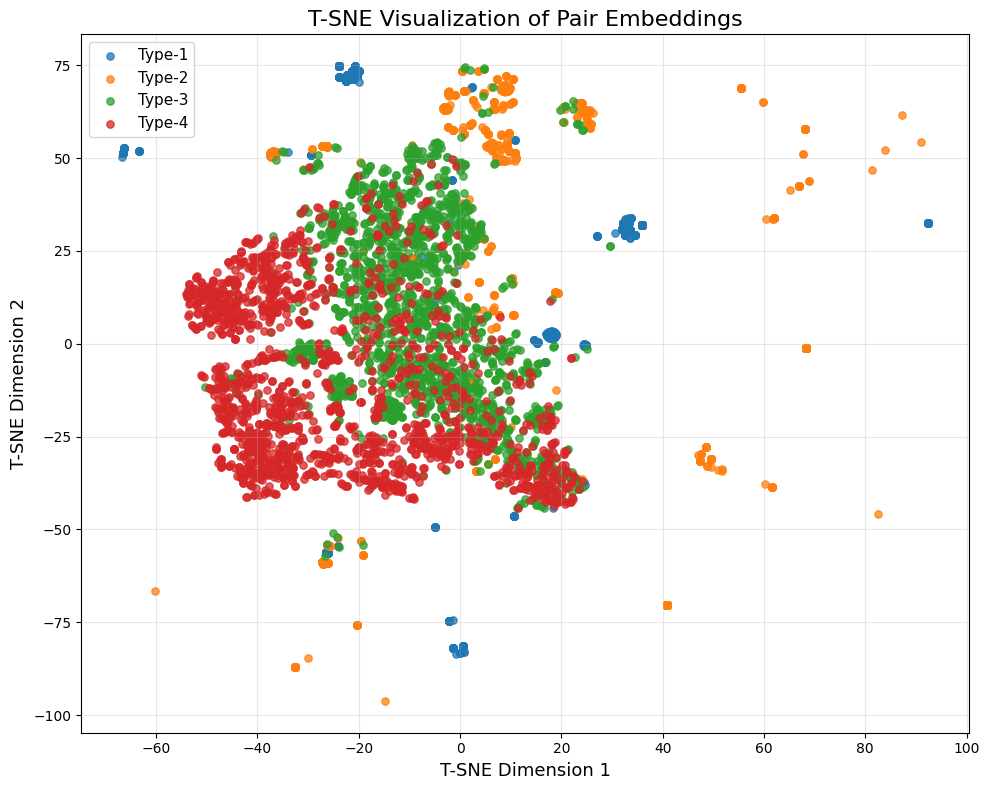

Saved T-SNE figure to: /kaggle/working/tsne_test.png


In [41]:
# =========================
# 2. Plot T-SNE
# =========================

def plot_tsne(
    embeddings,
    labels,
    class_names=None,
    save_path="/kaggle/working/tsne_test.png",
    random_state=42
):
    class_names = class_names or ["Type-1", "Type-2", "Type-3", "Type-4"]

    n_samples = embeddings.shape[0]

    # Perplexity phải nhỏ hơn số mẫu
    perplexity = min(30, max(5, (n_samples - 1) // 3))

    print(f"Running T-SNE with perplexity={perplexity}, n_samples={n_samples}")

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=random_state
    )

    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))

    for cls_idx, cls_name in enumerate(class_names):
        idx = labels == cls_idx
        plt.scatter(
            embeddings_2d[idx, 0],
            embeddings_2d[idx, 1],
            s=28,
            alpha=0.75,
            label=cls_name
        )

    plt.title("T-SNE Visualization of Pair Embeddings", fontsize=16)
    plt.xlabel("T-SNE Dimension 1", fontsize=13)
    plt.ylabel("T-SNE Dimension 2", fontsize=13)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved T-SNE figure to: {save_path}")

    return embeddings_2d


tsne_2d = plot_tsne(
    z_embeddings,
    y_true,
    class_names=CLASS_NAMES,
    save_path="/kaggle/working/tsne_test.png"
)

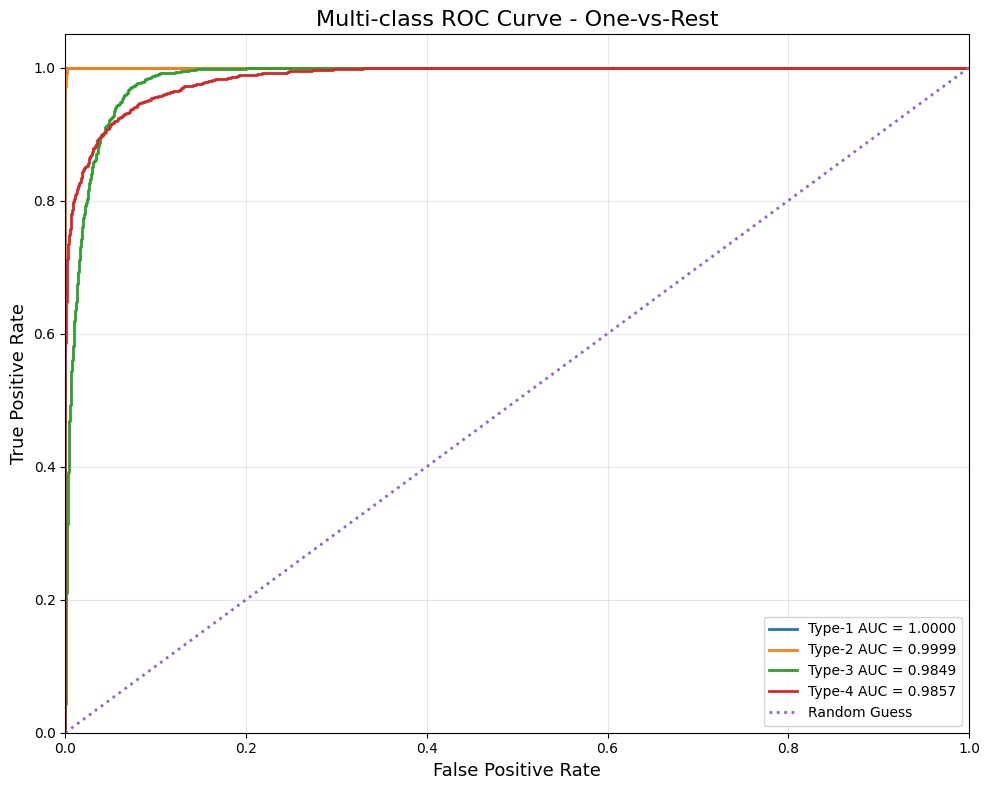

Saved ROC Curve figure to: /kaggle/working/roc_curve_test.png
ROC AUC scores:
0: 1.0000
1: 0.9999
2: 0.9849
3: 0.9857
micro: 0.9962


In [85]:
# =========================
# 3. Plot ROC Curve - Multi-class One-vs-Rest
# =========================

def plot_multiclass_roc(
    y_true,
    y_prob,
    num_classes=4,
    class_names=None,
    save_path="/kaggle/working/roc_curve_test.png"
):
    class_names = class_names or ["Type-1", "Type-2", "Type-3", "Type-4"]

    # One-hot nhãn thật
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    fpr = {}
    tpr = {}
    roc_auc = {}

    # ROC từng class theo One-vs-Rest
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average ROC
    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_true_bin.ravel(),
        y_prob.ravel()
    )
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.figure(figsize=(10, 8))

    for i in range(num_classes):
        plt.plot(
            fpr[i],
            tpr[i],
            linewidth=2,
            label=f"{class_names[i]} AUC = {roc_auc[i]:.4f}"
        )

    # plt.plot(
    #     fpr["micro"],
    #     tpr["micro"],
    #     linestyle="--",
    #     linewidth=2,
    #     label=f"Micro-average AUC = {roc_auc['micro']:.4f}"
    # )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle=":",
        linewidth=2,
        label="Random Guess"
    )

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate", fontsize=13)
    plt.ylabel("True Positive Rate", fontsize=13)
    plt.title("Multi-class ROC Curve - One-vs-Rest", fontsize=16)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved ROC Curve figure to: {save_path}")

    return roc_auc


roc_auc_scores = plot_multiclass_roc(
    y_true,
    y_prob,
    num_classes=NUM_CLASSES,
    class_names=CLASS_NAMES,
    save_path="/kaggle/working/roc_curve_test.png"
)

print("ROC AUC scores:")
for k, v in roc_auc_scores.items():
    print(f"{k}: {v:.4f}")

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 2. Plot T-SNE
# =========================

def plot_tsne(
    embeddings,
    labels,
    class_names=None,
    save_path="/kaggle/working/tsne_test.png",
    max_samples=3000,
    random_state=42
):
    class_names = class_names or ["Type-1", "Type-2", "Type-3", "Type-4"]

    embeddings = np.asarray(embeddings)
    labels = np.asarray(labels)

    # =========================
    # Lấy tối đa 3000 mẫu
    # =========================
    if embeddings.shape[0] > max_samples:
        all_idx = np.arange(embeddings.shape[0])

        _, sample_idx = train_test_split(
            all_idx,
            test_size=max_samples,
            random_state=random_state,
            stratify=labels
        )

        embeddings = embeddings[sample_idx]
        labels = labels[sample_idx]

    n_samples = embeddings.shape[0]

    # Perplexity phải nhỏ hơn số mẫu
    perplexity = min(30, max(5, (n_samples - 1) // 3))

    print(f"Running T-SNE with perplexity={perplexity}, n_samples={n_samples}")

    # Giảm chiều trước bằng PCA cho nhanh hơn
    if embeddings.shape[1] > 50:
        embeddings = PCA(
            n_components=50,
            random_state=random_state
        ).fit_transform(embeddings)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        method="barnes_hut",
        random_state=random_state,
        max_iter=1000,
        verbose=1
    )

    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))

    for cls_idx, cls_name in enumerate(class_names):
        idx = labels == cls_idx
        plt.scatter(
            embeddings_2d[idx, 0],
            embeddings_2d[idx, 1],
            s=28,
            alpha=0.75,
            label=cls_name
        )

    plt.title("T-SNE Visualization of Pair Embeddings", fontsize=16)
    plt.xlabel("T-SNE Dimension 1", fontsize=13)
    plt.ylabel("T-SNE Dimension 2", fontsize=13)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved T-SNE figure to: {save_path}")

    return embeddings_2d

Running T-SNE with perplexity=30, n_samples=3000
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 3000 samples in 0.001s...
[t-SNE] Computed neighbors for 3000 samples in 0.158s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3000
[t-SNE] Computed conditional probabilities for sample 2000 / 3000
[t-SNE] Computed conditional probabilities for sample 3000 / 3000
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.863640
[t-SNE] KL divergence after 1000 iterations: 0.557906


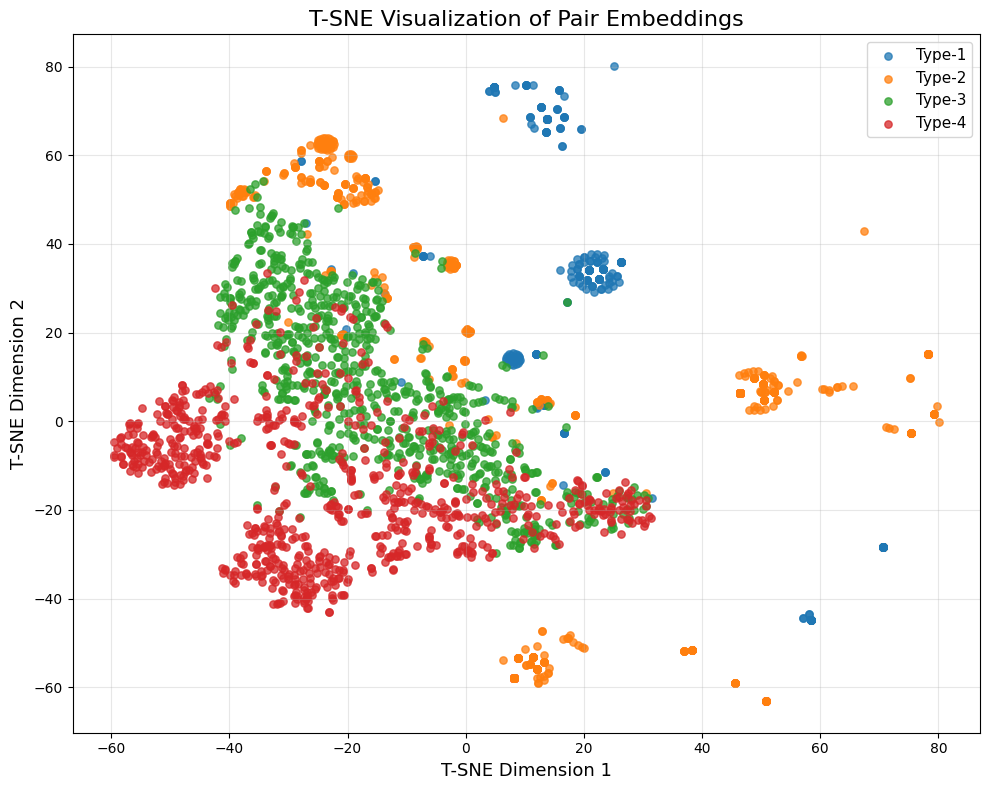

Saved T-SNE figure to: /kaggle/working/tsne_test.png


In [52]:
tsne_2d = plot_tsne(
    z_embeddings,
    y_true,
    class_names=CLASS_NAMES,
    save_path="/kaggle/working/tsne_test.png",
    max_samples=3000
)